# Feature Engineering

**Covers:**
- IP address → country geolocation
- Time features (hour_of_day, day_of_week, time_since_signup)
- Transaction velocity
- Encoding + scaling
- SMOTE for class imbalance


In [2]:
import pandas as pd
import numpy as np
import socket
import struct
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid')

## 1. Load Cleaned Data

In [3]:
df = pd.read_csv('data/processed/fraud_data_cleaned.csv', parse_dates=['signup_time', 'purchase_time'])
ip_ranges = pd.read_csv('data/raw/IpAddress_to_Country.csv')
print(df.shape, ip_ranges.shape)

(151112, 11) (138846, 3)


## 2. IP Address → Country (Geolocation)

In [4]:
def ip_to_int(ip_val):
    """Convert IP to integer — handles both float and dotted-notation formats."""
    try:
        f = float(ip_val)
        return int(f)
    except (ValueError, TypeError):
        pass
    try:
        return struct.unpack('!I', socket.inet_aton(str(ip_val)))[0]
    except Exception:
        return np.nan

df['ip_int'] = df['ip_address'].apply(ip_to_int)
ip_ranges['lower_int'] = ip_ranges['lower_bound_ip_address'].apply(ip_to_int)
ip_ranges['upper_int'] = ip_ranges['upper_bound_ip_address'].apply(ip_to_int)

ip_ranges_sorted = ip_ranges.dropna().sort_values('lower_int').reset_index(drop=True)
df_sorted = df.dropna(subset=['ip_int']).sort_values('ip_int').reset_index(drop=True)

# Range-based merge
merged = pd.merge_asof(
    df_sorted,
    ip_ranges_sorted[['lower_int', 'upper_int', 'country']],
    left_on='ip_int',
    right_on='lower_int',
    direction='backward'
)
merged = merged[merged['ip_int'] <= merged['upper_int']].copy()
merged['country'] = merged['country'].fillna('Unknown')

print(f'Rows before: {len(df_sorted)}, after merge: {len(merged)}')
print('Country assigned to % of rows:', round(100 * merged['country'].ne('Unknown').mean(), 2))

Rows before: 151112, after merge: 129146
Country assigned to % of rows: 100.0


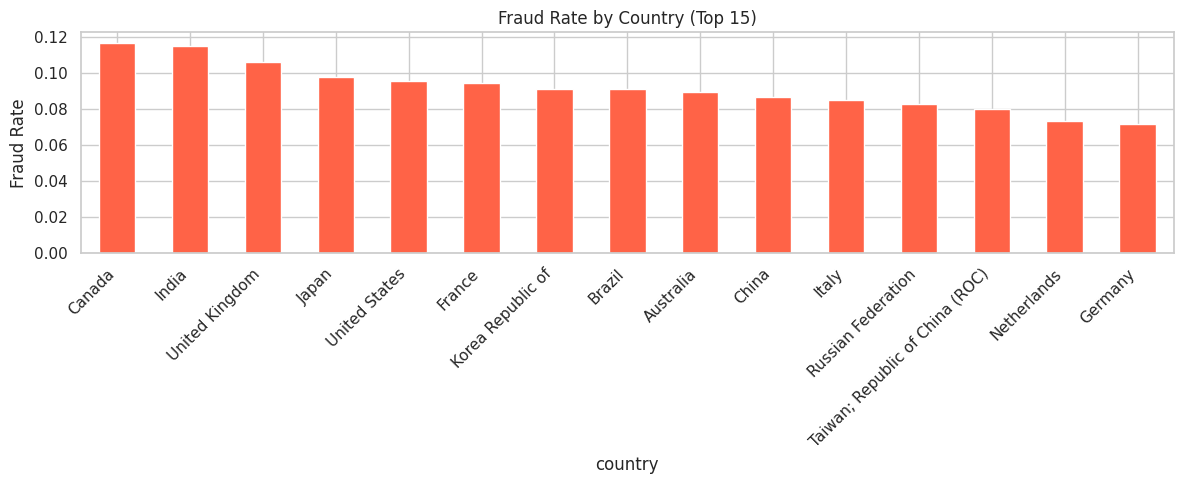

In [5]:
# Fraud rate by top 15 countries
top_countries = merged['country'].value_counts().head(15).index
fraud_by_country = (
    merged[merged['country'].isin(top_countries)]
    .groupby('country')['class'].mean()
    .sort_values(ascending=False)
)
fig, ax = plt.subplots(figsize=(12, 5))
fraud_by_country.plot(kind='bar', ax=ax, color='tomato')
ax.set_title('Fraud Rate by Country (Top 15)')
ax.set_ylabel('Fraud Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Time Features

In [ ]:
merged['time_since_signup'] = (
    merged['purchase_time'] - merged['signup_time']
).dt.total_seconds() / 3600  # hours

merged['hour_of_day'] = merged['purchase_time'].dt.hour
merged['day_of_week'] = merged['purchase_time'].dt.dayofweek

print(merged[['time_since_signup', 'hour_of_day', 'day_of_week']].describe())

In [ ]:
# Fraud rate by hour of day
fig, ax = plt.subplots(figsize=(12, 4))
merged.groupby('hour_of_day')['class'].mean().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Fraud Rate by Hour of Day')
ax.set_ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

## 4. Transaction Velocity

In [ ]:
# Count total transactions per user (as a simple velocity proxy)
user_tx_count = merged.groupby('user_id')['purchase_time'].count().rename('user_tx_count')
merged = merged.merge(user_tx_count, on='user_id', how='left')

print(merged[['user_tx_count', 'class']].groupby('class').describe())

## 5. Encoding & Scaling

In [ ]:
# Drop columns not needed for modeling
drop_cols = ['user_id', 'device_id', 'ip_address', 'signup_time', 'purchase_time',
             'ip_int', 'lower_int', 'upper_int']
model_df = merged.drop(columns=[c for c in drop_cols if c in merged.columns], errors='ignore')

# One-hot encode categoricals
cat_cols = ['source', 'browser', 'sex', 'country']
model_df = pd.get_dummies(model_df, columns=[c for c in cat_cols if c in model_df.columns])

# Scale numerical features
num_cols = ['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'day_of_week', 'user_tx_count']
num_cols = [c for c in num_cols if c in model_df.columns]

scaler = StandardScaler()
model_df[num_cols] = scaler.fit_transform(model_df[num_cols])

print(f'Final shape: {model_df.shape}')
model_df.head()

## 6. Train/Test Split + SMOTE

In [ ]:
X = model_df.drop(columns=['class'])
y = model_df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Before SMOTE:', y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('After SMOTE:', pd.Series(y_train_res).value_counts().to_dict())

## 7. Save Processed Data

In [ ]:
import joblib

X_train_res.to_csv('data/processed/X_train_fraud.csv', index=False)
X_test.to_csv('data/processed/X_test_fraud.csv', index=False)
pd.Series(y_train_res).to_csv('data/processed/y_train_fraud.csv', index=False)
y_test.to_csv('data/processed/y_test_fraud.csv', index=False)

joblib.dump(scaler, 'models/scaler_fraud.joblib')
print('Saved train/test splits and scaler.')